# Assignment 3
Daniel Evans

## Imports & Setup

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data_path = "data/diabetes.csv"

df = pd.read_csv(data_path)

# Figures optionally saved at the end of the notebook
save_figures = False

# Sample for parts A and B
sample = df.sample(n=25, random_state=54984)

## Part A

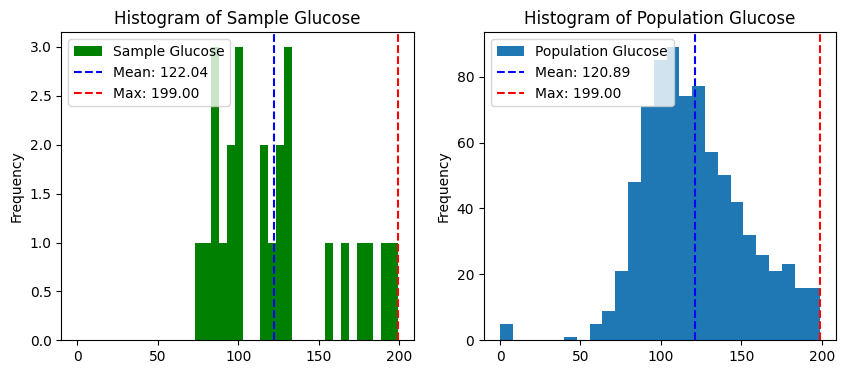

In [36]:
# Part A environment
fig_a, axes_a = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# Part A sample plot
sample_glucose_mean = sample.Glucose.mean()
sample_glucose_max = sample.Glucose.max()

sample.Glucose.plot(
    kind="hist",
    bins=25,
    color="green",
    ax=axes_a[0],
    label="Sample Glucose",
    title="Histogram of Sample Glucose",
)

axes_a[0].axvline(
    sample_glucose_mean,
    color="blue",
    linestyle="--",
    label=f"Mean: {sample_glucose_mean:.2f}",
)

axes_a[0].axvline(
    sample_glucose_max,
    color="red",
    linestyle="--",
    label=f"Max: {sample_glucose_max:.2f}",
)

axes_a[0].legend()

# Part A population plot
df.Glucose.plot(
    kind="hist",
    bins=25,
    ax=axes_a[1],
    label="Population Glucose",
    title="Histogram of Population Glucose",
)

pop_glucose_mean = df.Glucose.mean()
pop_glucose_max = df.Glucose.max()

axes_a[1].axvline(
    pop_glucose_mean,
    color="blue",
    linestyle="--",
    label=f"Mean: {pop_glucose_mean:.2f}",
)
axes_a[1].axvline(
    pop_glucose_max,
    color="red",
    linestyle="--",
    label=f"Max: {pop_glucose_max:.2f}"
)

axes_a[1].legend()

plt.show()

## Part B

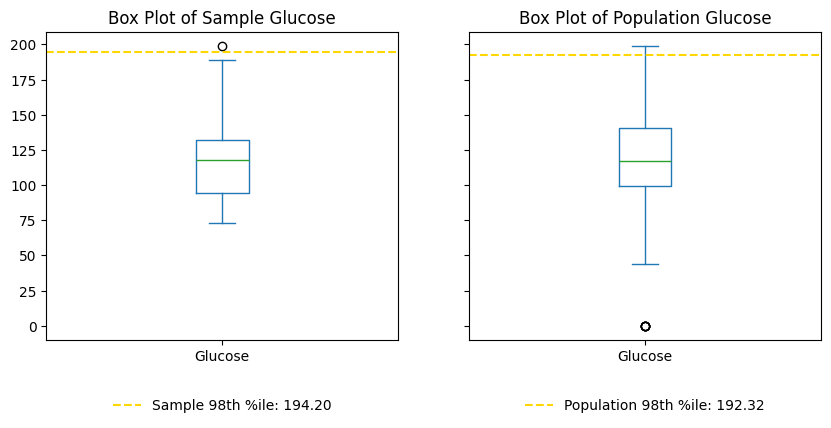

In [37]:
# Part B environment
fig_b, axes_b = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Part B sample plot
sample.Glucose.plot(
    kind="box",
    ax=axes_b[0],
    title="Box Plot of Sample Glucose"
)

sample_glucose_98th = sample.Glucose.quantile(0.98)

axes_b[0].axhline(
    sample_glucose_98th,
    color="gold",
    linestyle="--",
    label=f"Sample 98th %ile: {sample_glucose_98th:.2f}"
)

axes_b[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    frameon=False
)

df.Glucose.plot(
    kind="box", ax=axes_b[1],
    title="Box Plot of Population Glucose"
)

# Part B population plot
pop_glucose_98th = df.Glucose.quantile(0.98)

axes_b[1].axhline(
    pop_glucose_98th,
    color="gold",
    linestyle="--",
    label=f"Population 98th %ile: {pop_glucose_98th:.2f}"
)

axes_b[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    frameon=False
)

plt.show()

## Part C

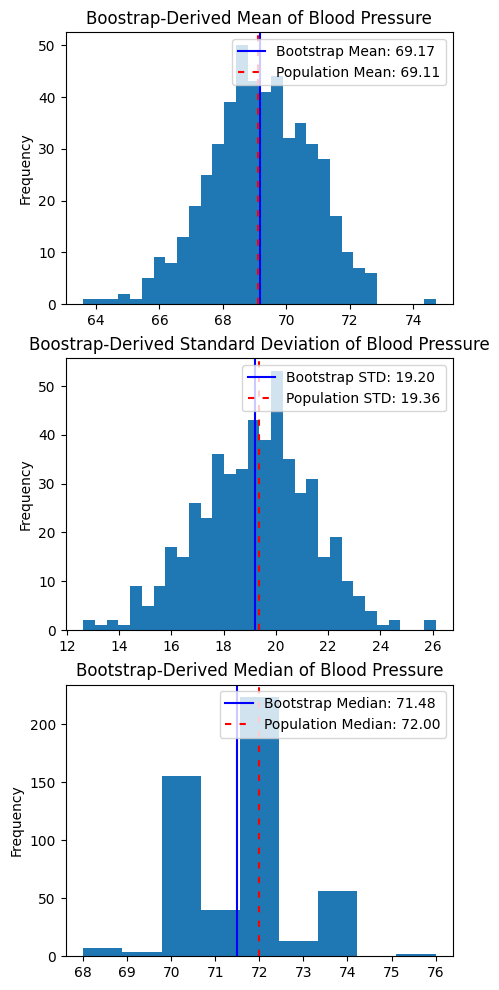

In [38]:
# Part C environment
fig_c, axes_c = plt.subplots(3, 1, figsize=(5, 12))

# Get population statistics
pop_bp_mean = df.BloodPressure.mean()
pop_bp_std = df.BloodPressure.std()
pop_bp_median = df.BloodPressure.median()

# Bootstrap sample for mean, standard deviation, and median
bootstrap_means = []
bootstrap_stds = []
bootstrap_medians = []

# set number of samples
n = 500

# set random seeds

for i in range(500):
    sample = df.sample(n=150, replace=True, random_state=i)
    bootstrap_means.append(sample.BloodPressure.mean())
    bootstrap_stds.append(sample.BloodPressure.std())
    bootstrap_medians.append(sample.BloodPressure.median())

bootstrap_means = pd.Series(bootstrap_means)
bootstrap_stds = pd.Series(bootstrap_stds)
bootstrap_medians = pd.Series(bootstrap_medians)

bootstrap_mean = bootstrap_means.mean()
bootstrap_std = bootstrap_stds.mean()
bootstrap_median = bootstrap_medians.mean()

# Part C mean
bootstrap_means.plot(
    kind="hist",
    bins=30,
    ax=axes_c[0],
    label="",
    title="Boostrap-Derived Mean of Blood Pressure",
)

axes_c[0].axvline(
    bootstrap_mean,
    color="blue",
    label=f"Bootstrap Mean: {bootstrap_mean:.2f}",
)
axes_c[0].axvline(
    pop_bp_mean,
    color="red",
    linestyle=(0, (3, 4)),
    label=f"Population Mean: {pop_bp_mean:.2f}"
)

axes_c[0].legend()

# Part C standard deviation
bootstrap_stds.plot(
    kind="hist",
    bins=30,
    ax=axes_c[1],
    label="",
    title="Boostrap-Derived Standard Deviation of Blood Pressure",
)

axes_c[1].axvline(
    bootstrap_std,
    color="blue",
    label=f"Bootstrap STD: {bootstrap_std:.2f}",
)
axes_c[1].axvline(
    pop_bp_std,
    color="red",
    linestyle=(0, (3, 4)),
    label=f"Population STD: {pop_bp_std:.2f}"
)

axes_c[1].legend()

# Part C medians
bootstrap_medians.plot(
    kind="hist",
    bins=9,
    ax=axes_c[2],
    label="",
    title="Bootstrap-Derived Median of Blood Pressure",
)

axes_c[2].axvline(
    bootstrap_median,
    color="blue",
    label=f"Bootstrap Median: {bootstrap_median:.2f}",
)
axes_c[2].axvline(
    pop_bp_median,
    color="red",
    linestyle=(0, (3, 4)),
    label=f"Population Median: {pop_bp_median:.2f}"
)

axes_c[2].legend()

plt.show()

For each statistic (mean, standard deviation, and median), the bootstrap-derived value closely approximates the corresponding population statistic.

## Save Figures

Save figures here, if `save_figures` is set to `True` at the top of this notebook

In [39]:
if save_figures:
    fig_a.savefig(
        'figures/fig_a.png',
        dpi=300,
        bbox_inches='tight',
        format='png',
        transparent=False
    )

    fig_b.savefig(
        'figures/fig_b.png',
        dpi=300,
        bbox_inches='tight',
        format='png',
        transparent=False
    )

    fig_c.savefig(
        'figures/fig_c.png',
        dpi=300,
        bbox_inches='tight',
        format='png',
        transparent=False
    )